# Modélisation – Expérience de robustesse sans la variable `conso_mixte`

## Objectif de la modélisation

À l'issue des étapes d'exploration, de visualisation et de prétraitement des données, le jeu de données est désormais prêt à être exploité dans le cadre de la phase de modélisation.

L'objectif de cette étape est de construire un ou plusieurs modèles de régression capables de prédire les émissions de dioxyde de carbone (CO₂) des véhicules à partir de leurs caractéristiques techniques et énergétiques.

Plusieurs modèles de régression seront entraînés puis comparés afin d'identifier celui offrant les meilleures performances prédictives. L'évaluation reposera principalement sur les métriques MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) et R² (coefficient de détermination). La MAPE (Mean Absolute Percentage Error) pourra également être utilisée à titre complémentaire.

Conformément aux objectifs du projet, une attention particulière sera portée aux performances des modèles. Leur interprétabilité sera également prise en compte afin de faciliter l'analyse des résultats et la compréhension de l'influence des variables explicatives sur les émissions de CO₂.

## Expérience : suppression de la variable `conso_mixte`

Une seconde expérimentation est réalisée afin d'évaluer la robustesse des modèles de régression. La variable `conso_mixte`, très fortement corrélée aux émissions de CO₂, est volontairement retirée des variables explicatives.

L'objectif est d'analyser l'impact de cette suppression sur les performances des différents modèles et de déterminer leur capacité à prédire les émissions de CO₂ à partir des seules caractéristiques techniques des véhicules.

In [1]:
# Import des bibliothèques

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

## Chargement des jeux de données prétraités

Les jeux de données préparés lors de la phase de prétraitement sont chargés afin d'être utilisés pour l'entraînement et l'évaluation des différents modèles de régression.

In [2]:
# Import des bibliothèques

import pandas as pd
import numpy as np

# Chargement des jeux de données

X_train = pd.read_csv("../data/X_train_final.csv")
X_test = pd.read_csv("../data/X_test_final.csv")

y_train = pd.read_csv("../data/y_train.csv")["co2"]
y_test = pd.read_csv("../data/y_test.csv")["co2"]

In [3]:
# Suppression de la variable conso_mixte afin d'évaluer la robustesse des modèles

X_train = X_train.drop(columns=["conso_mixte"])
X_test = X_test.drop(columns=["conso_mixte"])

print("Nouvelle dimension de X_train :", X_train.shape)
print("Nouvelle dimension de X_test :", X_test.shape)

Nouvelle dimension de X_train : (44008, 90)
Nouvelle dimension de X_test : (11002, 90)


## Vérification des jeux de données

Avant de débuter l'entraînement des modèles, une vérification des dimensions des jeux de données est réalisée afin de s'assurer de leur cohérence.

In [4]:
print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)

print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (44008, 90)
Dimensions de X_test  : (11002, 90)
Dimensions de y_train : (44008,)
Dimensions de y_test  : (11002,)


In [5]:
X_train.head()

,puiss_max,co_typ_1,nox,ptcl,masse_ordma_min,masse_ordma_max,lib_mrq_ASTON MARTIN,lib_mrq_AUDI,lib_mrq_BENTLEY,lib_mrq_BMW,...,typ_boite_nb_rapp_A 9,typ_boite_nb_rapp_D 5,typ_boite_nb_rapp_D 6,typ_boite_nb_rapp_D 7,typ_boite_nb_rapp_M 5,typ_boite_nb_rapp_M 6,typ_boite_nb_rapp_M 7,typ_boite_nb_rapp_S 6,typ_boite_nb_rapp_V .,typ_boite_nb_rapp_V 0
0,100.0,0.203,0.214,0.001,1976,2739,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,190.0,0.227,0.030,0.001,2075,2075,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100.0,0.006,0.211,0.000,2356,2585,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,120.0,0.046,0.197,0.000,2076,2185,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,125.0,0.440,0.030,0.001,1380,1380,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Présentation des jeux de données

Les jeux de données utilisés pour la modélisation sont désormais entièrement numériques et prêts à être exploités par les différents algorithmes de Machine Learning.

Le jeu d'entraînement (`X_train`) est utilisé pour apprendre les relations entre les variables explicatives et les émissions de CO₂, tandis que le jeu de test (`X_test`) permet d'évaluer les performances des modèles sur des données jamais vues pendant l'entraînement.

Les variables catégorielles ont été transformées par encodage One-Hot lors de la phase de prétraitement, ce qui permet à l'ensemble des modèles de travailler exclusivement sur des variables numériques.

In [6]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 44008 entries, 0 to 44007
Data columns (total 90 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   puiss_max                        44008 non-null  float64
 1   co_typ_1                         44008 non-null  float64
 2   nox                              44008 non-null  float64
 3   ptcl                             44008 non-null  float64
 4   masse_ordma_min                  44008 non-null  int64  
 5   masse_ordma_max                  44008 non-null  int64  
 6   lib_mrq_ASTON MARTIN             44008 non-null  float64
 7   lib_mrq_AUDI                     44008 non-null  float64
 8   lib_mrq_BENTLEY                  44008 non-null  float64
 9   lib_mrq_BMW                      44008 non-null  float64
 10  lib_mrq_CADILLAC                 44008 non-null  float64
 11  lib_mrq_CHEVROLET                44008 non-null  float64
 12  lib_mrq_CITROEN              

In [7]:
X_train.describe()

,puiss_max,co_typ_1,nox,ptcl,masse_ordma_min,masse_ordma_max,lib_mrq_ASTON MARTIN,lib_mrq_AUDI,lib_mrq_BENTLEY,lib_mrq_BMW,...,typ_boite_nb_rapp_A 9,typ_boite_nb_rapp_D 5,typ_boite_nb_rapp_D 6,typ_boite_nb_rapp_D 7,typ_boite_nb_rapp_M 5,typ_boite_nb_rapp_M 6,typ_boite_nb_rapp_M 7,typ_boite_nb_rapp_S 6,typ_boite_nb_rapp_V .,typ_boite_nb_rapp_V 0
count,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,...,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000
mean,118.898580,0.181001,0.299977,0.000900,2103.603368,2343.286153,0.001409,0.006113,0.000432,0.008385,...,0.000636,0.001113,0.000500,0.000432,0.018042,0.579213,0.000273,0.000023,0.000045,0.005431
std,44.945937,0.144890,0.418767,0.000972,294.011894,423.211581,0.037508,0.077944,0.020774,0.091185,...,0.025216,0.033350,0.022353,0.020774,0.133105,0.493691,0.016511,0.004767,0.006741,0.073495
min,28.000000,0.005000,0.000000,0.000000,825.000000,825.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.000000,0.061000,0.197000,0.000000,1982.000000,2075.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,120.000000,0.137000,0.214000,0.001000,2076.000000,2355.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,120.000000,0.296000,0.228000,0.001000,2246.000000,2709.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,585.000000,0.968000,1.846000,0.023000,2760.000000,3094.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Vérification finale des jeux de données

Avant d'entraîner les modèles, une dernière vérification est réalisée afin de confirmer l'absence de valeurs manquantes dans les jeux d'entraînement et de test. Cette étape garantit que les données sont prêtes pour la modélisation.

In [8]:
# Vérification finale des valeurs manquantes

print("Nombre total de NaN dans X_train :", X_train.isna().sum().sum())
print("Nombre total de NaN dans X_test  :", X_test.isna().sum().sum())

print("Nombre total de NaN dans y_train :", y_train.isna().sum())
print("Nombre total de NaN dans y_test  :", y_test.isna().sum())

Nombre total de NaN dans X_train : 0
Nombre total de NaN dans X_test  : 0
Nombre total de NaN dans y_train : 0
Nombre total de NaN dans y_test  : 0


## Régression linéaire

La régression linéaire constitue le modèle de référence (baseline) de notre étude. Son principe repose sur l'hypothèse d'une relation linéaire entre les variables explicatives et les émissions de CO₂.

Ce modèle présente plusieurs avantages : il est rapide à entraîner, simple à interpréter et permet d'identifier l'influence des différentes variables sur la variable cible. Il servira de point de comparaison pour évaluer les performances des modèles plus complexes étudiés par la suite.

### Entraînement du modèle

In [12]:
# Initialisation du modèle
reg_lin = LinearRegression()

# Entraînement
reg_lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prédictions

In [13]:
y_pred_lin = reg_lin.predict(X_test)

### Évaluation

In [14]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin)

print(f"MAE  : {mae_lin:.2f}")
print(f"RMSE : {rmse_lin:.2f}")
print(f"R²   : {r2_lin:.4f}")
print(f"MAPE : {mape_lin:.4f}")

MAE  : 9.59
RMSE : 12.90
R²   : 0.8593
MAPE : 0.0496


### Vérification de la capacité de généralisation

In [15]:
print("Score R² sur le jeu d'entraînement :", reg_lin.score(X_train, y_train))
print("Score R² sur le jeu de test         :", reg_lin.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.8604768618455098
Score R² sur le jeu de test         : 0.8593448727631536


Les coefficients de détermination obtenus sur les jeux d'entraînement (R² = 0,8605) et de test (R² = 0,8593) sont très proches.

Cet écart très faible montre que la régression linéaire conserve une excellente capacité de généralisation malgré la suppression de la variable `conso_mixte`. Le modèle ne présente pas de surapprentissage significatif.

### Interprétation des résultats

La régression linéaire conserve de bonnes performances malgré la suppression de la variable `conso_mixte`.

Le coefficient de détermination (R² = 0,8593) montre que le modèle explique près de 86 % de la variabilité des émissions de CO₂. Les erreurs de prédiction augmentent par rapport au modèle initial (MAE = 9,59 g/km ; RMSE = 12,90 g/km ; MAPE = 4,96 %), ce qui confirme que `conso_mixte` constituait une variable particulièrement informative.

Néanmoins, les performances restent satisfaisantes et montrent que les autres caractéristiques techniques des véhicules apportent également une information importante pour la prédiction des émissions de CO₂.

## Régression Ridge

La régression Ridge est une extension de la régression linéaire qui intègre une pénalisation de type L2 sur les coefficients du modèle.

Cette régularisation permet de limiter l'influence des variables fortement corrélées et de réduire le risque de surapprentissage. Elle est particulièrement adaptée lorsque le jeu de données comporte un grand nombre de variables explicatives, comme c'est le cas après l'encodage One-Hot des variables catégorielles.

L'objectif est d'évaluer si cette pénalisation améliore les performances prédictives par rapport à la régression linéaire classique.

### Entraînement du modèle

In [22]:
from sklearn.linear_model import Ridge

# Initialisation du modèle
ridge = Ridge(alpha=1.0)

# Entraînement
ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### Prédictions

In [23]:
# Prédictions sur le jeu de test
y_pred_ridge = ridge.predict(X_test)

### Évaluation

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)

print(f"MAE  : {mae_ridge:.2f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"R²   : {r2_ridge:.4f}")
print(f"MAPE : {mape_ridge:.4f}")

MAE  : 9.61
RMSE : 12.92
R²   : 0.8589
MAPE : 0.0496


### Vérification de la capacité de généralisation

In [25]:
print("Score R² sur le jeu d'entraînement :", ridge.score(X_train, y_train))
print("Score R² sur le jeu de test         :", ridge.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.8602064361108317
Score R² sur le jeu de test         : 0.8588724120129698


### Interprétation des résultats
La régression Ridge présente des performances très proches de celles de la régression linéaire.

Le coefficient de détermination (R² = 0,8589) montre que le modèle explique près de 86 % de la variabilité des émissions de CO₂. Les erreurs de prédiction (MAE = 9,61 g/km ; RMSE = 12,92 g/km ; MAPE = 4,96 %) restent contenues malgré la suppression de `conso_mixte`.

Les scores obtenus sur les jeux d'entraînement et de test sont très proches, ce qui confirme une bonne capacité de généralisation. Dans cette expérience, la régularisation L2 n'apporte pas d'amélioration notable par rapport à la régression linéaire.

## Régression Lasso

La régression Lasso est une variante de la régression linéaire qui applique une pénalisation de type L1 sur les coefficients du modèle.

Contrairement à la régression Ridge, cette pénalisation peut réduire certains coefficients exactement à zéro, réalisant ainsi une sélection automatique des variables les moins pertinentes. Cette propriété permet d'obtenir des modèles plus simples et potentiellement plus interprétables.

L'objectif est d'évaluer si cette régularisation améliore les performances prédictives tout en simplifiant le modèle.

### Entraînement du modèle

In [17]:
from sklearn.linear_model import Lasso

# Initialisation du modèle
lasso = Lasso(alpha=1.0)

# Entraînement
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Prédictions

In [18]:
# Prédictions sur le jeu de test
y_pred_lasso = lasso.predict(X_test)

### Évaluation

In [19]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)

print(f"MAE  : {mae_lasso:.2f}")
print(f"RMSE : {rmse_lasso:.2f}")
print(f"R²   : {r2_lasso:.4f}")
print(f"MAPE : {mape_lasso:.4f}")

MAE  : 12.41
RMSE : 17.25
R²   : 0.7486
MAPE : 0.0647


### Vérification de la capacité de généralisation

In [20]:
print("Score R² sur le jeu d'entraînement :", lasso.score(X_train, y_train))
print("Score R² sur le jeu de test         :", lasso.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.7557889402315195
Score R² sur le jeu de test         : 0.7485527749390988


### Interprétation des résultats

La régression Lasso est le modèle linéaire le plus affecté par la suppression de `conso_mixte`.

Le coefficient de détermination (R² = 0,7486) montre que le modèle explique environ 75 % de la variabilité des émissions de CO₂. Les erreurs de prédiction augmentent sensiblement (MAE = 12,41 g/km ; RMSE = 17,25 g/km ; MAPE = 6,47 %).

La pénalisation L1 élimine certaines variables explicatives en plus de `conso_mixte`, ce qui réduit davantage l'information disponible pour la prédiction et explique cette baisse de performances.

## Arbre de décision

L'arbre de décision est un modèle non linéaire capable de capturer des relations complexes entre les variables explicatives et la variable cible.

Contrairement aux modèles de régression linéaire, Ridge et Lasso, il ne suppose aucune relation linéaire entre les variables. Il segmente progressivement les données en fonction des variables les plus discriminantes afin de minimiser l'erreur de prédiction.

L'objectif est d'évaluer si cette approche permet d'améliorer les performances prédictives par rapport aux modèles linéaires.

### Entraînement du modèle

In [27]:
from sklearn.tree import DecisionTreeRegressor

# Initialisation du modèle
tree = DecisionTreeRegressor(random_state=42)

# Entraînement
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### Prédictions

In [28]:
# Prédictions sur le jeu de test
y_pred_tree = tree.predict(X_test)

### Évaluation

In [29]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = mean_absolute_percentage_error(y_test, y_pred_tree)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R²   : {r2_tree:.4f}")
print(f"MAPE : {mape_tree:.4f}")

MAE  : 3.17
RMSE : 5.21
R²   : 0.9771
MAPE : 0.0172


### Vérification de la capacité de généralisation

In [30]:
print("Score R² sur le jeu d'entraînement :", tree.score(X_train, y_train))
print("Score R² sur le jeu de test         :", tree.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.9851391659645802
Score R² sur le jeu de test         : 0.9770580682081442


### Interprétation des résultats

L'arbre de décision demeure le modèle le plus performant malgré la suppression de `conso_mixte`.

Le coefficient de détermination (R² = 0,9771) montre que le modèle explique plus de 97 % de la variabilité des émissions de CO₂. Les erreurs de prédiction restent faibles (MAE = 3,17 g/km ; RMSE = 5,21 g/km ; MAPE = 1,72 %).

Un léger écart entre les scores d'entraînement (R² = 0,9851) et de test (R² = 0,9771) traduit un faible surapprentissage, phénomène classique pour un arbre de décision, sans remettre en cause ses excellentes performances.

### Importance des variables

In [31]:
import pandas as pd

importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": tree.feature_importances_
})

importance.sort_values("Importance", ascending=False).head(15)

,Variable,Importance
5,masse_ordma_max,0.4830
0,puiss_max,0.1901
50,cod_cbr_ES,0.1222
76,typ_boite_nb_rapp_A 5,0.0689
2,nox,0.0501
1,co_typ_1,0.0319
78,typ_boite_nb_rapp_A 7,0.0147
3,ptcl,0.0087
4,masse_ordma_min,0.0058
77,typ_boite_nb_rapp_A 6,0.0031


L'analyse de l'importance des variables montre qu'après la suppression de `conso_mixte`, l'arbre de décision s'appuie principalement sur la masse maximale du véhicule (`masse_ordma_max`), la puissance maximale (`puiss_max`) et le type de carburant (`cod_cbr_ES`).

Les émissions de NOx (`nox`) et de CO (`co_typ_1`) contribuent également à la prédiction, tandis que les autres variables présentent une importance plus limitée.

Ces résultats montrent que le modèle est capable de compenser l'absence de `conso_mixte` en exploitant efficacement les autres caractéristiques techniques des véhicules.

## Synthèse de l'expérience

Cette expérimentation met en évidence l'impact de la suppression de la variable `conso_mixte` sur les performances des différents modèles.

Les modèles de régression linéaire et Ridge conservent de bonnes performances, tandis que le modèle Lasso est davantage pénalisé. L'arbre de décision demeure le modèle le plus performant, ce qui montre qu'il est capable d'exploiter efficacement les autres caractéristiques techniques des véhicules pour prédire les émissions de CO₂.

## Comparaison des modèles

Les performances des différents modèles de régression sont comparées à l'aide de quatre indicateurs : le MAE (Mean Absolute Error), le RMSE (Root Mean Squared Error), le coefficient de détermination (R²) et le MAPE (Mean Absolute Percentage Error).

Cette comparaison permet d'identifier le modèle offrant le meilleur compromis entre précision des prédictions et capacité de généralisation.

In [32]:
comparaison = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Ridge",
        "Lasso",
        "Arbre de décision"
    ],
    "MAE": [
        mae_lin,
        mae_ridge,
        mae_lasso,
        mae_tree
    ],
    "RMSE": [
        rmse_lin,
        rmse_ridge,
        rmse_lasso,
        rmse_tree
    ],
    "R²": [
        r2_lin,
        r2_ridge,
        r2_lasso,
        r2_tree
    ],
    "MAPE": [
        mape_lin,
        mape_ridge,
        mape_lasso,
        mape_tree
    ]
})

comparaison = comparaison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4,
    "MAPE": 4
})

comparaison

,Modèle,MAE,RMSE,R²,MAPE
0,Régression linéaire,9.5900,12.9000,0.8593,0.0496
1,Ridge,9.6100,12.9200,0.8589,0.0496
2,Lasso,12.4100,17.2500,0.7486,0.0647
3,Arbre de décision,3.1700,5.2100,0.9771,0.0172


### Analyse comparative des modèles

La suppression de `conso_mixte` entraîne une diminution des performances de l'ensemble des modèles, mais avec une intensité variable.

Les régressions linéaire et Ridge conservent des performances satisfaisantes avec un coefficient de détermination proche de 0,86, montrant que les autres caractéristiques techniques restent fortement explicatives.

Le modèle Lasso est le plus pénalisé (R² = 0,7486), en raison de sa régularisation L1 qui réduit également l'influence d'autres variables explicatives.

L'arbre de décision demeure le modèle le plus performant (R² = 0,9771). Il exploite efficacement les interactions entre les variables restantes, notamment la masse, la puissance et le type de carburant, ce qui lui permet de maintenir un excellent niveau de prédiction malgré l'absence de `conso_mixte`.

## Conclusion générale de la modélisation

Cette expérimentation avait pour objectif d'évaluer l'influence de la variable `conso_mixte` sur les performances des différents modèles de régression.

La suppression de cette variable entraîne une diminution des performances des modèles linéaires et du modèle Lasso, confirmant que la consommation mixte constitue un prédicteur majeur des émissions de CO₂.

En revanche, l'arbre de décision conserve d'excellentes performances (R² = 0,9771), démontrant sa capacité à exploiter efficacement les interactions entre les autres variables du jeu de données, notamment la masse du véhicule, la puissance et le type de carburant.

Cette analyse met en évidence la robustesse des modèles et montre que les émissions de CO₂ peuvent être estimées de manière fiable même en l'absence de la variable `conso_mixte`, en particulier avec les modèles basés sur les arbres de décision.

Ci-dessus les tests ajoutés par Larissa:
- traitement avec Lazy Predict sur dataset sans la variable conso_mixte
- interpretabilité de 4 models avec SHAP:
    - linear Regression
    - Ridge
    - Lasso
    - Arbre de decisions

In [9]:

import os

os.environ["JOBLIB_START_METHOD"] = "fork"

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from lazypredict import LazyRegressor
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1)).fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



reg = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None )
models,predictions = reg.fit(X_train_scaled, X_test_scaled, y_train, y_test)

models_display = models.copy()

# Arrondi des colonnes numériques
models_display = models_display.round(4)

# Affichage sans notation scientifique
pd.set_option(
    'display.float_format',
    lambda x: f'{x:.4f}'
)

display(models_display)

models_display.to_excel(
    "LazyPredict_resultats.xlsx"
)

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.9813,0.9814,4.6883,3.2252
RandomForestRegressor,0.9782,0.9784,5.0573,4.7196
DecisionTreeRegressor,0.9769,0.9771,5.2098,0.1036
BaggingRegressor,0.9761,0.9763,5.2933,0.5120
ExtraTreeRegressor,0.9754,0.9756,5.3691,0.0766
HistGradientBoostingRegressor,0.9707,0.9709,5.8678,2.0487
MLPRegressor,0.9624,0.9627,6.6418,11.6150
KNeighborsRegressor,0.9532,0.9535,7.4144,1.0117
GradientBoostingRegressor,0.9487,0.9492,7.7555,2.9046


EXPLICABILITE DU MODELE LINEAR REGRESSION AVEC SHAP

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


Dimension des valeurs SHAP : (1000, 90)


,Variable,SHAP
78,typ_boite_nb_rapp_A 7,-12.8522
65,Carrosserie_MINIBUS,11.5829
85,typ_boite_nb_rapp_M 6,11.0713
5,masse_ordma_max,10.6134
0,puiss_max,6.2387
...,...,...
52,cod_cbr_ES/GP,0.0000
53,cod_cbr_FE,0.0000
54,cod_cbr_GH,0.0000
21,lib_mrq_JEEP,0.0000


Position dans l'échantillon : 59
Index d'origine : 18137


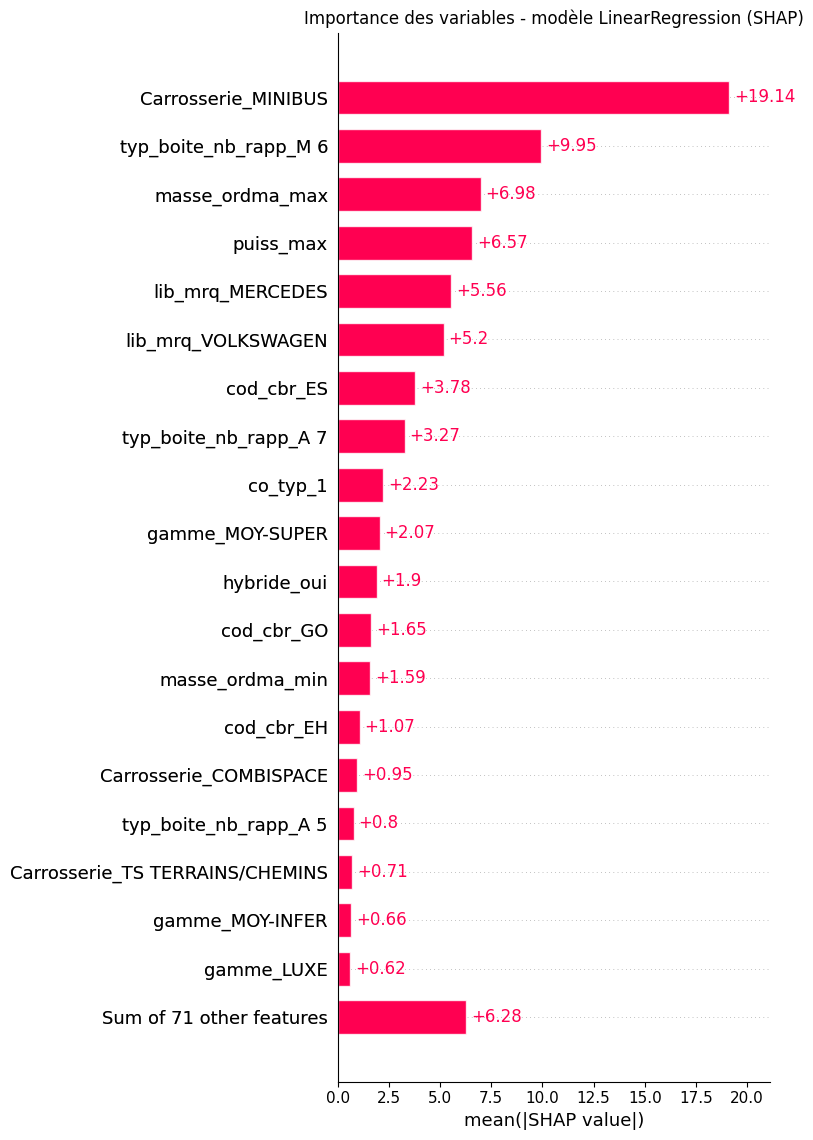

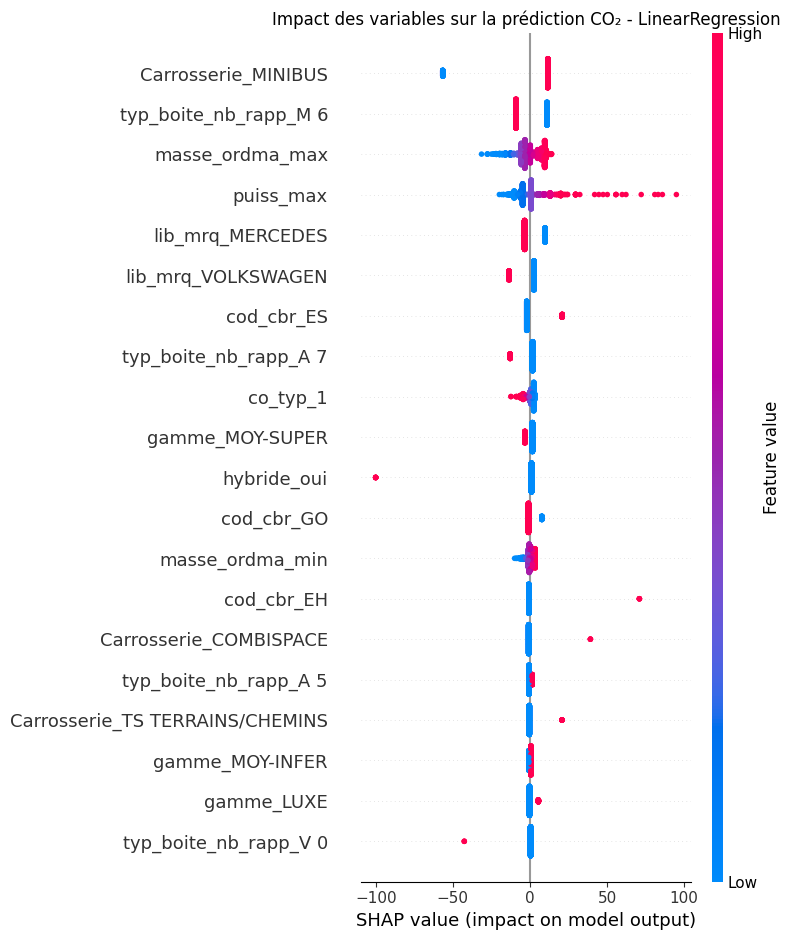

Explication de la prédiction du véhicule : 59
Index réel du véhicule : 18137


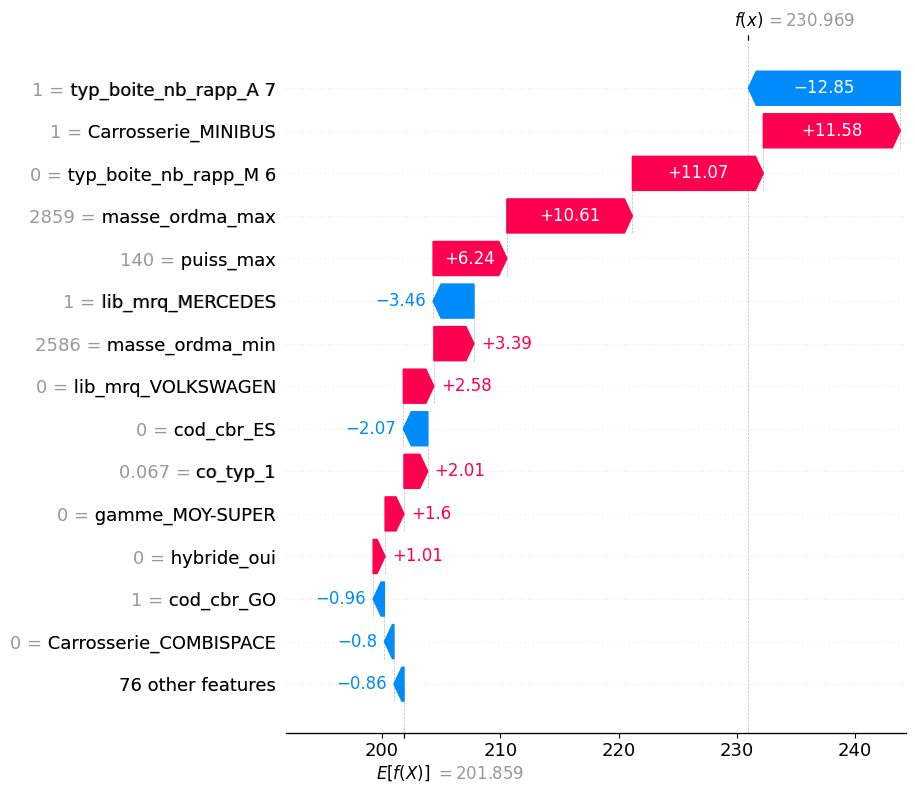

In [37]:
# ==========================================================
# EXPLICABILITE DU MODELE LINEAR REGRESSION AVEC SHAP
# ==========================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd


# ----------------------------------------------------------
# 1) Echantillon de X_train pour le calcul SHAP
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)


# ----------------------------------------------------------
# 2) Dataset de référence pour SHAP (background)
# ----------------------------------------------------------

X_background = X_train.sample(
    1000,
    random_state=42
)


# ----------------------------------------------------------
# 3) Création de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.LinearExplainer(
    reg_lin,
    X_background
)


# ----------------------------------------------------------
# 4) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)


# Vérification
print(
    "Dimension des valeurs SHAP :",
    shap_values.values.shape
)



# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))


# Affichage des valeurs SHAP d'un véhicule
display(
    pd.DataFrame(
        {
            "Variable": X_train_sample.columns,
            "SHAP": shap_values.values[59]
        }
    )
    .sort_values(
        "SHAP",
        key=abs,
        ascending=False
    )
)


print(
    "Position dans l'échantillon :",
    59
)

print(
    "Index d'origine :",
    X_train_sample.index[59]
)



shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)


plt.title(
    "Importance des variables - modèle LinearRegression (SHAP)"
)

plt.tight_layout()

plt.show()



# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LE CO2
# ==========================================================

plt.figure(figsize=(12, 8))


shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)


plt.title(
    "Impact des variables sur la prédiction CO₂ - LinearRegression"
)


plt.tight_layout()

plt.show()



# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PREDICTION INDIVIDUELLE
# ==========================================================

index = 59


print(
    "Explication de la prédiction du véhicule :",
    index
)


print(
    "Index réel du véhicule :",
    X_train_sample.index[index]
)


shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

EXPLICABILITE DU MODELE LASSO AVEC SHAP

Background dataset has 44008 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=44008 when initializing the masker.


Dimension des valeurs SHAP : (1000, 90)


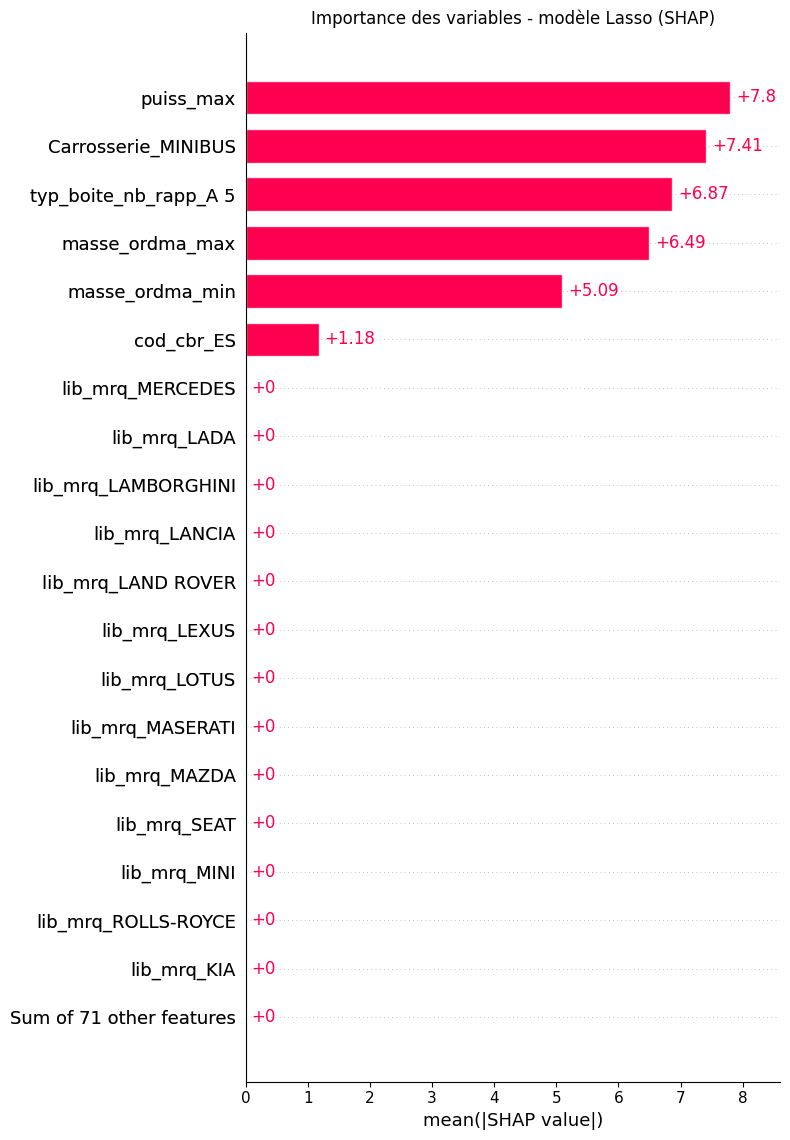

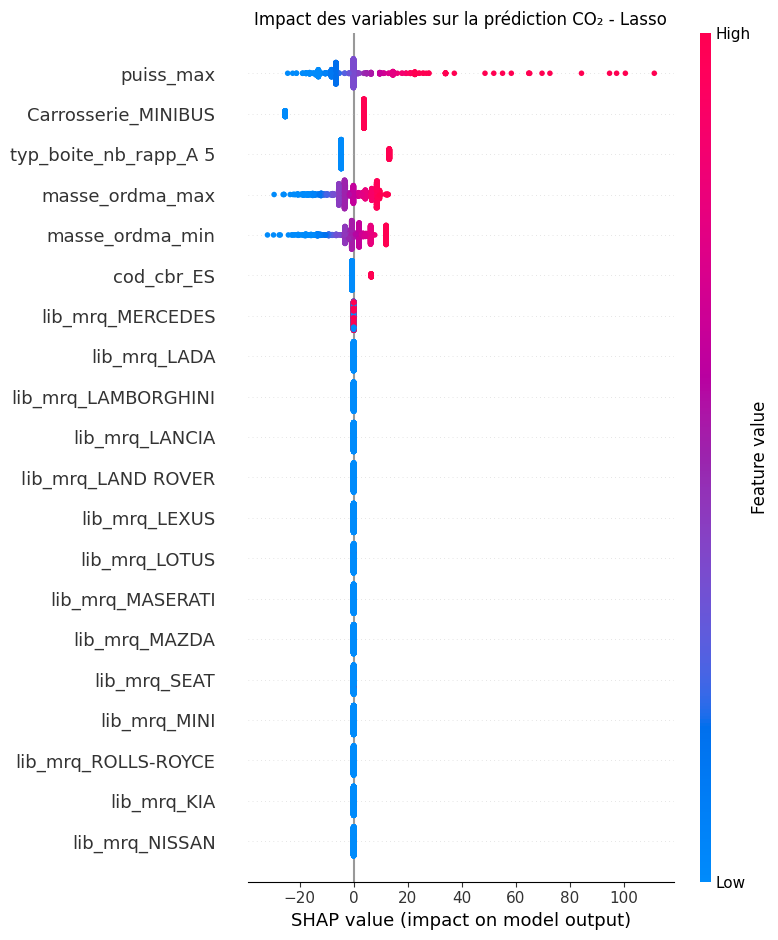

Explication de la prédiction du véhicule : 59
Index réel dans X_train : 18137


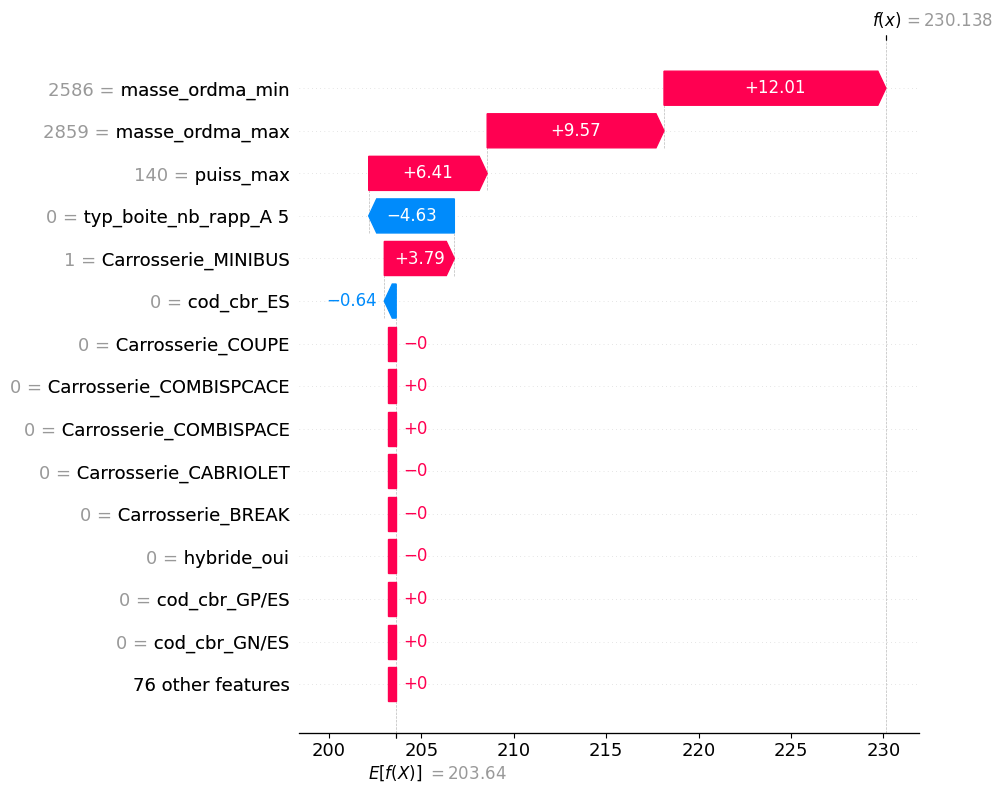

In [36]:
# ==========================================================
# EXPLICABILITE DU MODELE LASSO AVEC SHAP
# ==========================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd


# ----------------------------------------------------------
# 1) Echantillon de X_train pour le calcul SHAP
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)


# ----------------------------------------------------------
# 2) Création de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.LinearExplainer(
    lasso,
    X_train
)


# ----------------------------------------------------------
# 3) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)


# Vérification
print(
    "Dimension des valeurs SHAP :",
    shap_values.values.shape
)



# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - modèle Lasso (SHAP)"
)

plt.tight_layout()
plt.show()



# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LA PREDICTION CO2
# ==========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction CO₂ - Lasso"
)

plt.tight_layout()
plt.show()



# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PREDICTION INDIVIDUELLE
# ==========================================================

index = 59


print(
    "Explication de la prédiction du véhicule :",
    index
)

print(
    "Index réel dans X_train :",
    X_train_sample.index[index]
)


shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

EXPLICABILITE DU MODELE RIDGE AVEC SHAP

Background dataset has 44008 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=44008 when initializing the masker.


Dimension SHAP : (1000, 90)


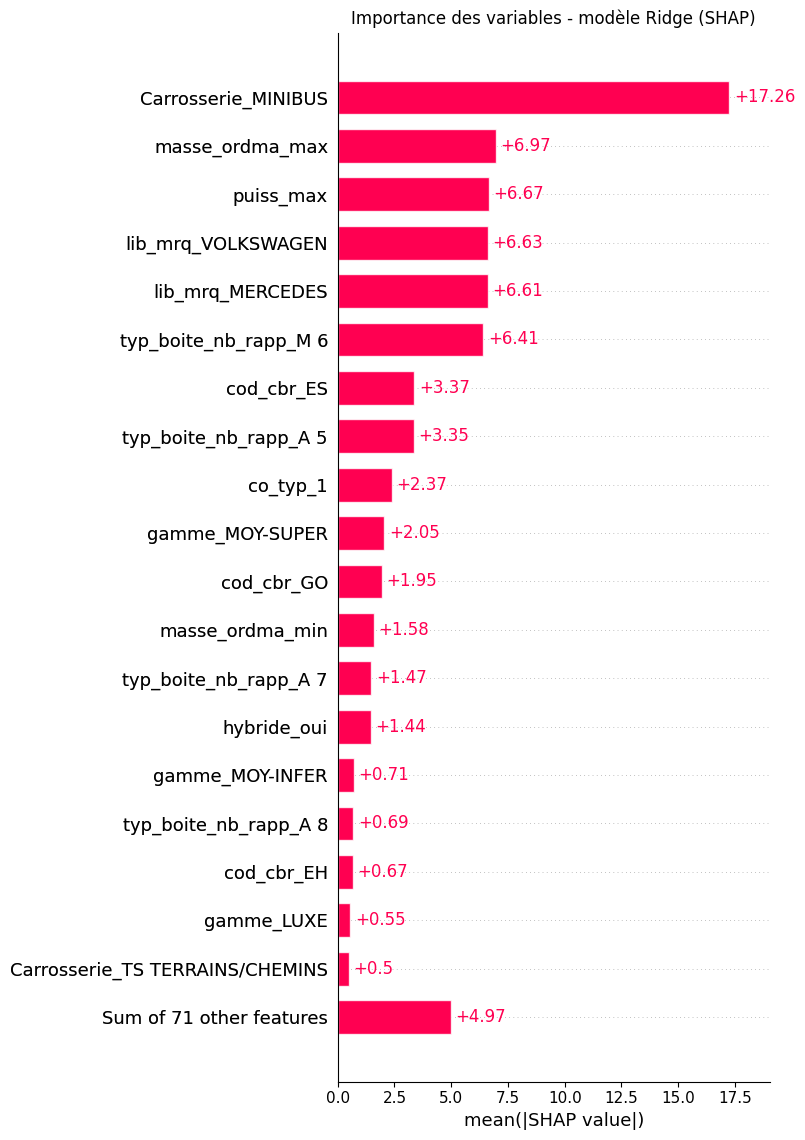

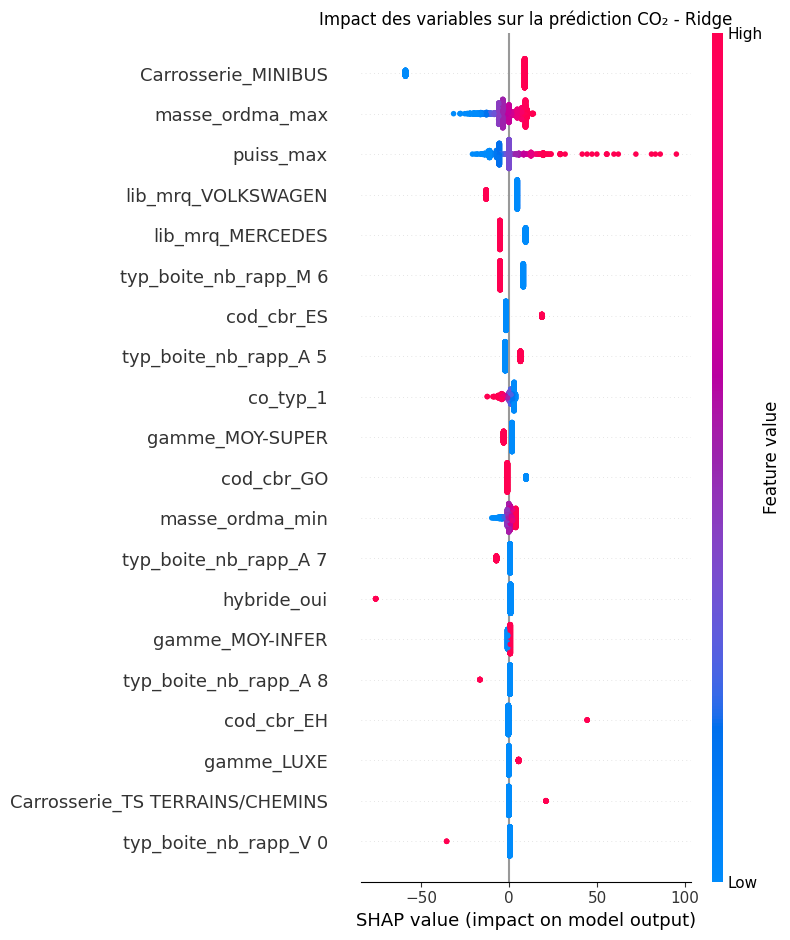

Explication de la prédiction du véhicule : 59
Index réel : 18137


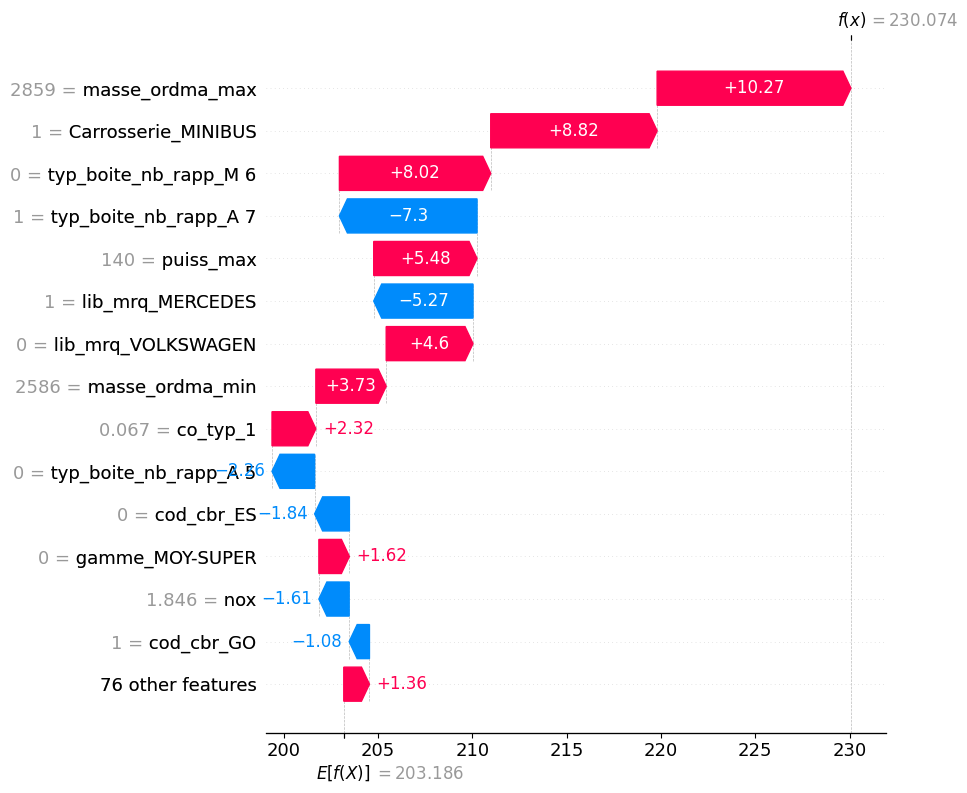

In [35]:
# ==========================================================
# EXPLICABILITE DU MODELE RIDGE AVEC SHAP
# ==========================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd


# ----------------------------------------------------------
# 1) Echantillon de X_train
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)


# ----------------------------------------------------------
# 2) Création de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.LinearExplainer(
    ridge,
    X_train
)


# ----------------------------------------------------------
# 3) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)


# Vérification
print("Dimension SHAP :", shap_values.values.shape)



# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE
# ==========================================================

plt.figure(figsize=(10,8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - modèle Ridge (SHAP)"
)

plt.tight_layout()
plt.show()



# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES
# ==========================================================

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction CO₂ - Ridge"
)

plt.tight_layout()
plt.show()



# ==========================================================
# GRAPHIQUE 3 : EXPLICATION INDIVIDUELLE
# ==========================================================

index = 59


print(
    "Explication de la prédiction du véhicule :",
    index
)

print(
    "Index réel :",
    X_train_sample.index[index]
)


shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

EXPLICABILITE DU MODELE DECISION TREE REGRESSOR AVEC SHAP

.values =
array([[-4.37628701e+00,  3.20079548e+00,  7.53323392e+00, ...,
         0.00000000e+00,  0.00000000e+00,  1.23077273e-02],
       [-3.49919861e+00, -4.97857769e+00,  9.97827711e+00, ...,
         0.00000000e+00,  0.00000000e+00,  1.25165221e-02],
       [-1.52058576e+00,  2.67761454e+00, -6.57350302e+00, ...,
         0.00000000e+00,  0.00000000e+00,  5.96444336e-03],
       ...,
       [ 4.54907997e+00, -2.77239421e+00, -3.19581625e+01, ...,
         0.00000000e+00,  0.00000000e+00,  2.75354025e-02],
       [-1.76709162e+00,  5.57954249e+00,  4.95805083e+00, ...,
         0.00000000e+00,  0.00000000e+00,  5.86486750e-03],
       [-1.92240524e+00, -2.26191951e+00,  3.00896163e+00, ...,
         0.00000000e+00,  0.00000000e+00,  4.92027297e-03]],
      shape=(1000, 90))

.base_values =
array([201.72725414, 201.72725414, 201.72725414, 201.72725414,
       201.72725414, 201.72725414, 201.72725414, 201.72725414,
       201.72725414, 201.72725414, 201.72725414, 201.72725414,
    

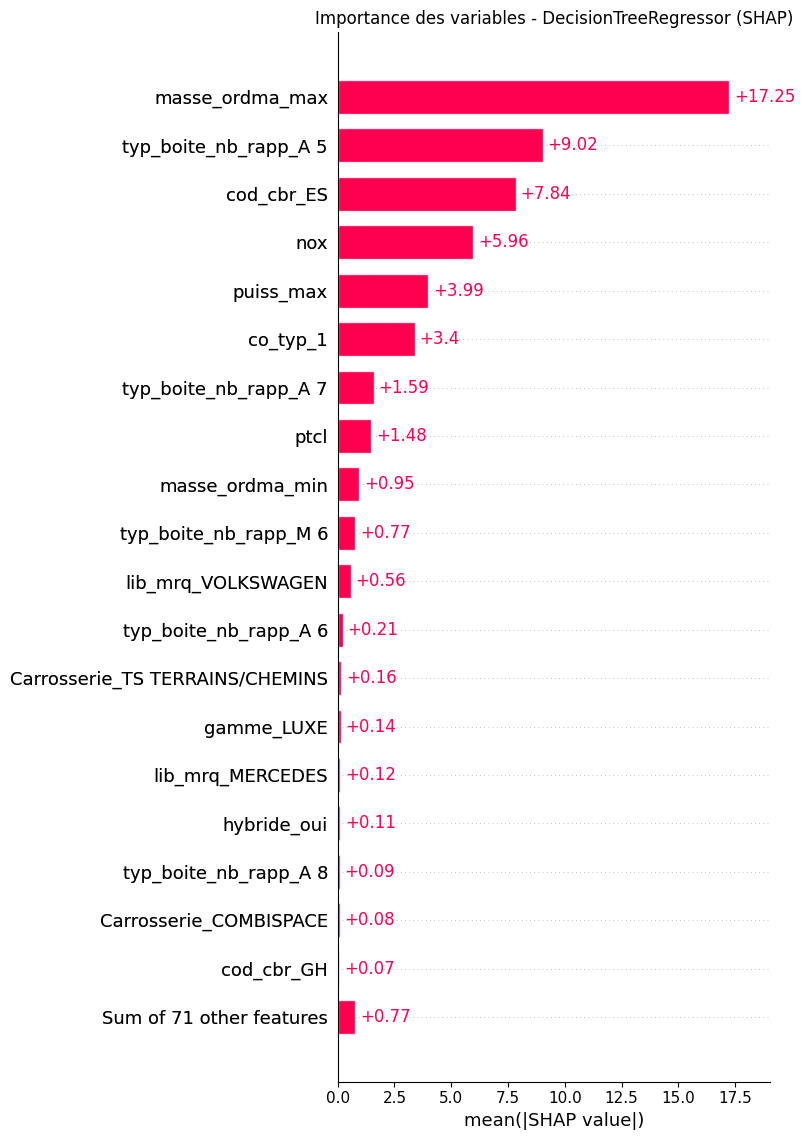

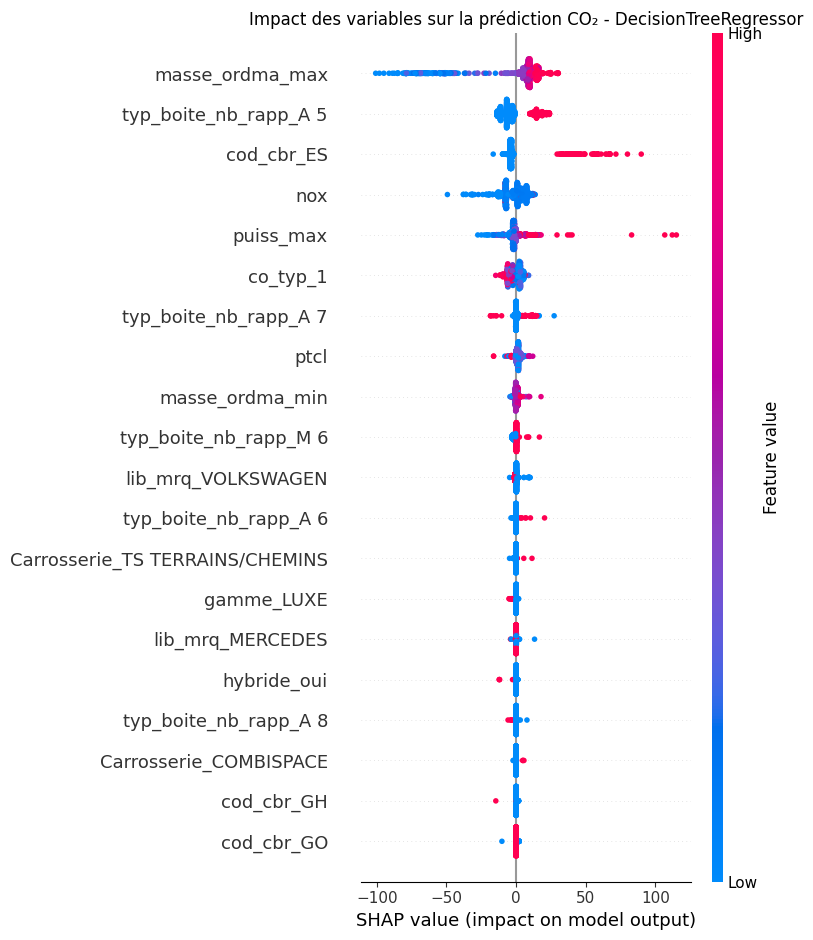

Explication de la prédiction du véhicule : 59
Index réel dans X_train : 18137


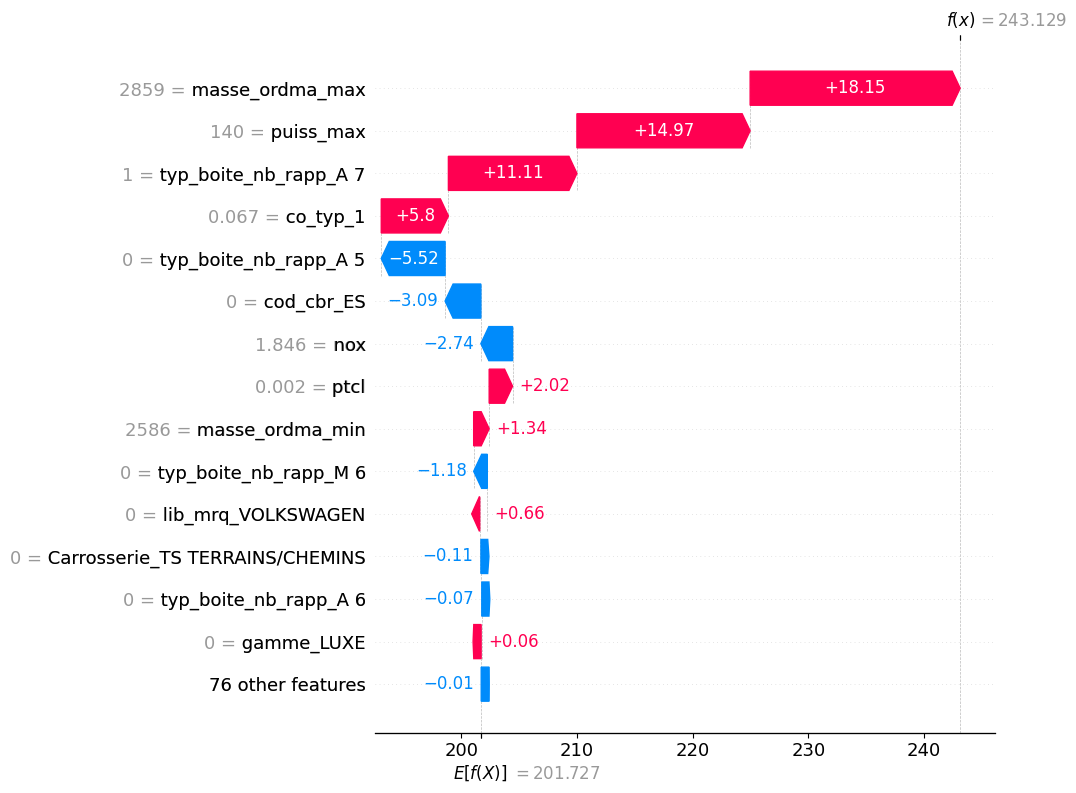

In [34]:
# ==========================================================
# EXPLICABILITE DECISION TREE REGRESSOR AVEC SHAP
# ==========================================================

import shap
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# 1) Echantillon de X_train
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)


# ----------------------------------------------------------
# 2) Création de l'explainer SHAP pour arbre
# ----------------------------------------------------------

explainer = shap.TreeExplainer(
    tree
)


# ----------------------------------------------------------
# 3) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)


# Vérification
print(shap_values)


# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - DecisionTreeRegressor (SHAP)"
)

plt.tight_layout()
plt.show()



# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LE CO2
# ==========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction CO₂ - DecisionTreeRegressor"
)

plt.tight_layout()
plt.show()



# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PREDICTION INDIVIDUELLE
# ==========================================================

index = 59


print(
    "Explication de la prédiction du véhicule :",
    index
)

print(
    "Index réel dans X_train :",
    X_train_sample.index[index]
)


shap.plots.waterfall(
    shap_values[index],
    max_display=15
)